# LOAN APPROVAL PREDICTION USING MACHINE LEARNING

**Name:** Ragini Singh  
**Roll No.:** 150096724023
**Course:** Machine Learning  
**Assignment:** Loan Approval Dataset Analysis and Prediction  

## Introduction

The loan approval dataset contains financial and personal information about loan applicants. The dataset includes details such as income, loan amount, loan term, CIBIL score, residential assets, commercial assets, luxury assets and bank assets.

The objective of this assignment is to explore the dataset, preprocess the data, identify important patterns and build a machine learning model to predict whether a loan application will be Approved or Rejected.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Loading the Dataset

In [3]:
# Load the dataset

file_path = "loan_approval_dataset.csv"

df = pd.read_csv(file_path)

# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

# Remove extra spaces from text values
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display first 5 rows

df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
# Display last 5 rows

df.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


## 2. Understanding the Dataset

In [6]:
# Number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4269
Number of columns: 13


In [7]:
# Display all column names

print("Columns in the dataset:")
for column in df.columns:
    print(column)

Columns in the dataset:
loan_id
no_of_dependents
education
self_employed
income_annum
loan_amount
loan_term
cibil_score
residential_assets_value
commercial_assets_value
luxury_assets_value
bank_asset_value
loan_status


In [8]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [9]:
# Statistical summary of numerical columns

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
## 3. Data Cleaning

In [10]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


In [11]:
# Total missing values

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [12]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
# Remove duplicate rows if any

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (4269, 13)


## 4. Target Variable Analysis

In [14]:
# Check unique values of loan status

print(df["loan_status"].unique())

['Approved' 'Rejected']


In [15]:
# Count Approved and Rejected applications

print(df["loan_status"].value_counts())

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


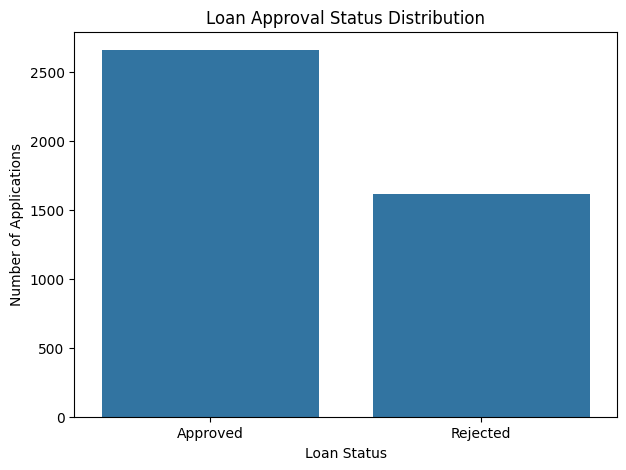

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Approval Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [17]:
# Check unique values in categorical columns

print("Education values:")
print(df["education"].value_counts())

print("\nSelf Employed values:")
print(df["self_employed"].value_counts())

Education values:
education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

Self Employed values:
self_employed
Yes    2150
No     2119
Name: count, dtype: int64


In [ ]:
## 5. Exploratory Data Analysis

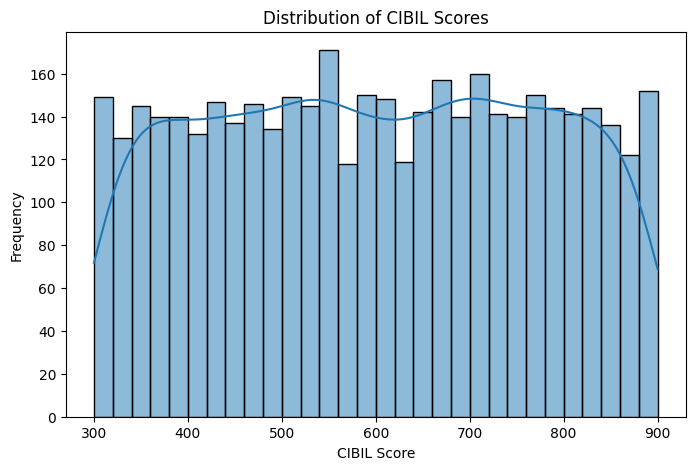

In [18]:
# Distribution of CIBIL score

plt.figure(figsize=(8, 5))

sns.histplot(df["cibil_score"], bins=30, kde=True)

plt.title("Distribution of CIBIL Scores")
plt.xlabel("CIBIL Score")
plt.ylabel("Frequency")

plt.show()

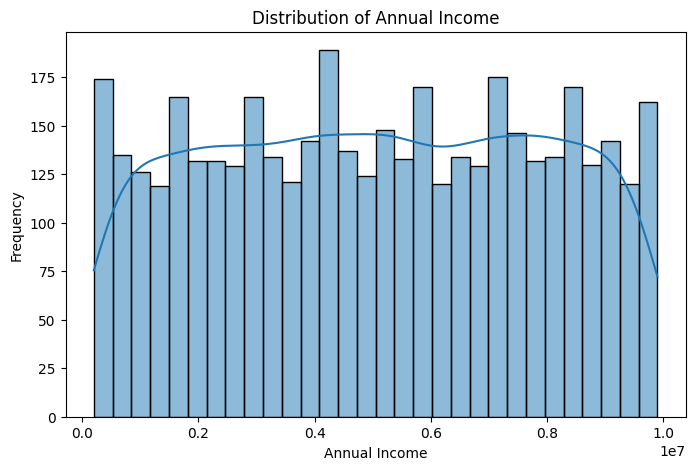

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(df["income_annum"], bins=30, kde=True)

plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Frequency")

plt.show()

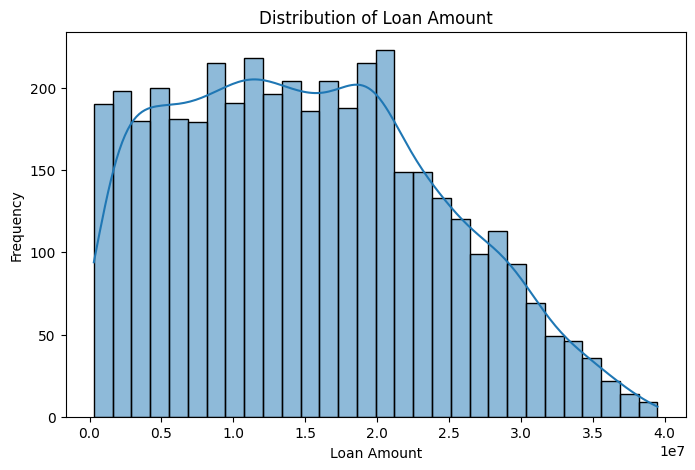

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(df["loan_amount"], bins=30, kde=True)

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

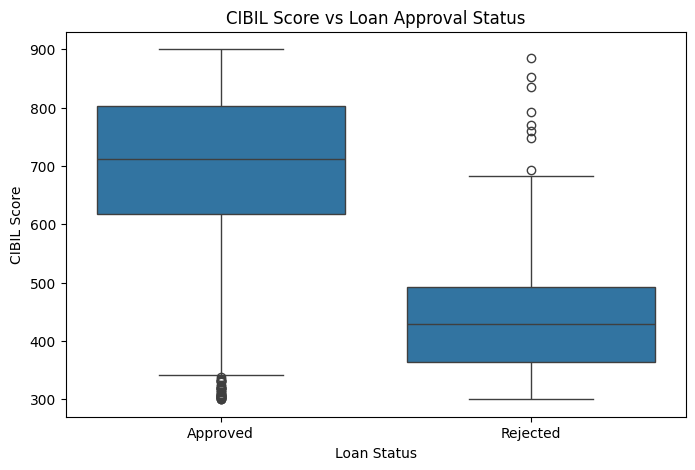

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="cibil_score")

plt.title("CIBIL Score vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("CIBIL Score")

plt.show()

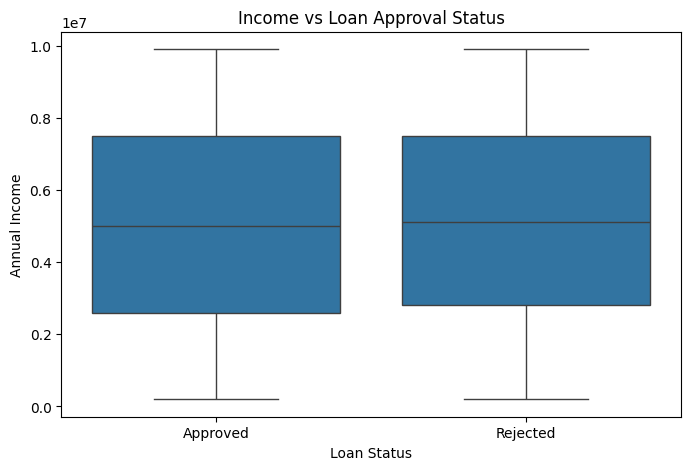

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="loan_status", y="income_annum")

plt.title("Income vs Loan Approval Status")
plt.xlabel("Loan Status")
plt.ylabel("Annual Income")

plt.show()

In [23]:
# Create a copy for correlation analysis

correlation_df = df.copy()

# Encode categorical columns
correlation_df["education"] = correlation_df["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

correlation_df["self_employed"] = correlation_df["self_employed"].map({
    "Yes": 1,
    "No": 0
})

correlation_df["loan_status"] = correlation_df["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

# Calculate correlation

correlation = correlation_df.corr(numeric_only=True)

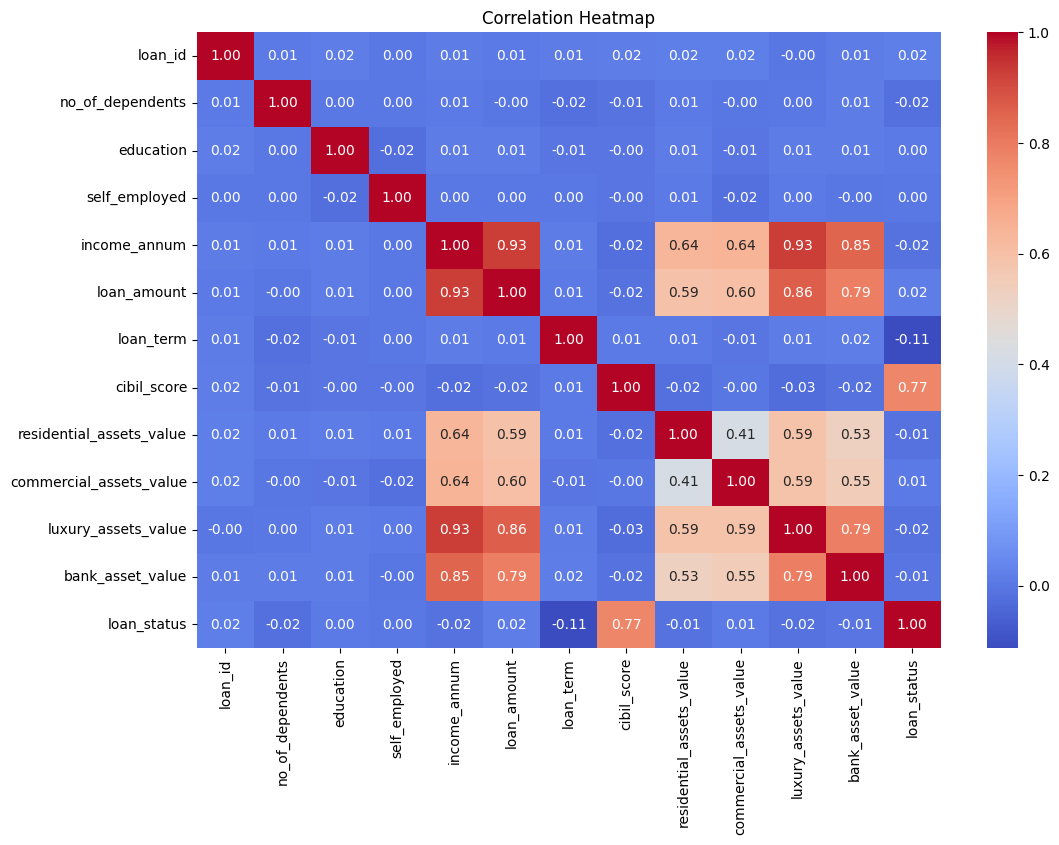

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## 6. Data Preprocessing

In [25]:
# Create a copy of the dataset

ml_data = df.copy()

# Encode categorical variables

ml_data["education"] = ml_data["education"].map({
    "Graduate": 1,
    "Not Graduate": 0
})

ml_data["self_employed"] = ml_data["self_employed"].map({
    "Yes": 1,
    "No": 0
})

# Encode target variable

ml_data["loan_status"] = ml_data["loan_status"].map({
    "Approved": 1,
    "Rejected": 0
})

print(ml_data.head())

   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          1              0       9600000   
1        2                 0          0              1       4100000   
2        3                 3          1              0       9100000   
3        4                 3          1              0       8200000   
4        5                 5          0              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  loan_status  
0                 17600000             22700000           8000000            

In [26]:
# Separate features and target

X = ml_data.drop(columns=["loan_status", "loan_id"])

y = ml_data["loan_status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4269, 11)
Target shape: (4269,)


## 7. Splitting the Dataset

In [27]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 11)
Testing data: (854, 11)


## 8. Building the Machine Learning Model

In [28]:
# Create Random Forest Classifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

In [29]:
# Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[1 0 0 1 1 1 1 0 1 0 0 0 1 0 1 0 0 1 1 0]


## 9. Model Evaluation

In [30]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 98.36%


In [31]:
# Classification report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Rejected", "Approved"]
))

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.98      0.97      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [32]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[314   9]
 [  5 526]]


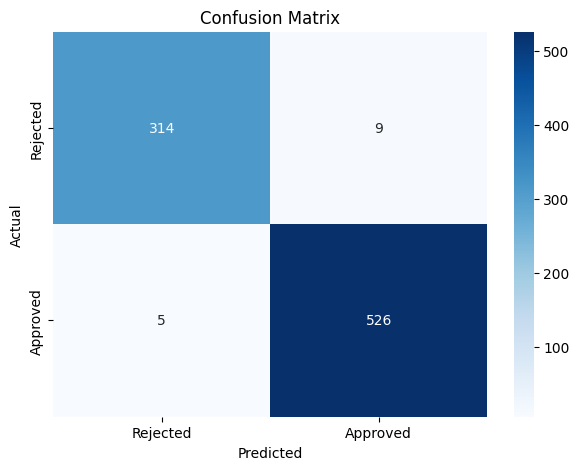

In [33]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rejected", "Approved"],
    yticklabels=["Rejected", "Approved"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                     Feature  Importance
6                cibil_score    0.804893
5                  loan_term    0.064627
4                loan_amount    0.030846
3               income_annum    0.019078
9        luxury_assets_value    0.018461
7   residential_assets_value    0.017235
8    commercial_assets_value    0.016568
10          bank_asset_value    0.015400
0           no_of_dependents    0.008091
2              self_employed    0.002520
1                  education    0.002280


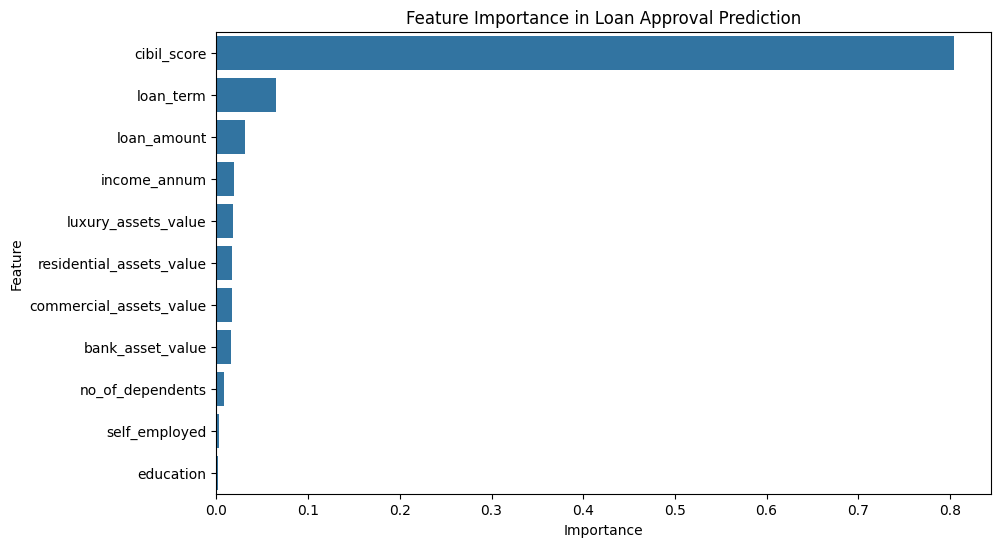

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance in Loan Approval Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()